# The Success of the restaurants in 2026

### First of all **WHAT IS SUCCESS ???** 

There are a lot of ways to measure "success", mainly 3:

- Perceived success: The rating, reviews, popularity. Easy to measure. Easy to find data. The problem -> Easy to manipulate. Restaurants buy reviews or delete the bad ones

- Economical success: Net profit, ROI, ROA, Customer Retention Rate... They are good indicators but the data about them is hard to find and create a dataframe for thousands of restaurants

- Gastronomical success: Technique, Quality, Product, Consistency... It indicates the Real quality but is really hard to measure with public data. 

This project will use ratings as a proxy for success, while acknowledging their limitations in capturing real quality and business performance so they will be critically evaluated
due to their inherent biases, ratings reflect accessibility, not excellence, a 4.8 rating might be technically mediocre and a 4.2 gastronomically excellent.
Success in restaurants is multi-dimensional 

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import yaml

In [2]:
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [3]:
df1 = pl.read_csv(config["input_data"]["file_1"])
df1

restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,claimed,awards,popularity_detailed,popularity_generic,top_tags,price_level,price_range,meals,cuisines,special_diets,features,vegetarian_friendly,vegan_options,gluten_free,original_open_hours,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,default_language,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""g10001637-d10002227""","""Le 147""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Haute-Vienne""","""Saint-Jouvent""","""10 Maison Neuve, 87510 Saint-J…",45.961674,1.169131,"""Claimed""",null,"""#1 of 2 Restaurants in Saint-J…","""#1 of 2 places to eat in Saint…","""Cheap Eats, French""","""€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Wheelch…","""N""","""N""","""N""",null,null,null,null,4.0,36.0,"""English""",2.0,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,null,null
"""g10001637-d14975787""","""Le Saint Jouvent""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Haute-Vienne""","""Saint-Jouvent""","""16 Place de l Eglise, 87510 Sa…",45.95704,1.20548,"""Unclaimed""",null,"""#2 of 2 Restaurants in Saint-J…","""#2 of 2 places to eat in Saint…","""Cheap Eats""","""€""",null,null,null,null,null,"""N""","""N""","""N""",null,null,null,null,4.0,5.0,"""All languages""",5.0,2.0,2.0,1.0,0.0,0.0,null,null,null,null,null
"""g10002858-d4586832""","""Au Bout du Pont""","""[""Europe"", ""France"", ""Centre-V…","""France""","""Centre-Val de Loire""","""Berry""","""Rivarennes""","""2 rue des Dames, 36800 Rivaren…",46.635895,1.386133,"""Claimed""",null,"""#1 of 1 Restaurant in Rivarenn…","""#1 of 1 places to eat in Rivar…","""Cheap Eats, French, European""","""€""",null,"""Dinner, Lunch, Drinks""","""French, European""",null,"""Reservations, Seating, Table S…","""N""","""N""","""N""",null,null,null,null,5.0,13.0,"""English""",4.0,3.0,1.0,0.0,0.0,0.0,null,null,null,null,null
"""g10002986-d3510044""","""Le Relais de Naiade""","""[""Europe"", ""France"", ""Nouvelle…","""France""","""Nouvelle-Aquitaine""","""Correze""","""Lacelle""","""9 avenue Porte de la Correze 1…",45.64261,1.82446,"""Claimed""",null,"""#1 of 1 Restaurant in Lacelle""","""#1 of 1 places to eat in Lacel…","""Cheap Eats, French""","""€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Serves …","""N""","""N""","""N""",null,null,null,null,4.0,34.0,"""English""",1.0,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,null,null
"""g10022428-d9767191""","""Relais Du MontSeigne""","""[""Europe"", ""France"", ""Occitani…","""France""","""Occitanie""","""Aveyron""","""Saint-Laurent-de-Levezou""","""route du Montseigne, 12620 Sai…",44.20886,2.96047,"""Unclaimed""",null,"""#1 of 1 Restaurant in Saint-La…","""#1 of 1 places to eat in Saint…","""Mid-range, French""","""€€-€€€""",null,"""Lunch, Dinner""","""French""",null,"""Reservations, Seating, Wheelch…","""N""","""N""","""N""",null,null,null,null,4.5,11.0,"""All languages""",11.0,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""g9710275-d10770782""","""Complex Popas Pacurari""","""[""Europe"", ""Romania"", ""Northea…","""Romania""","""Northeast Romania""","""Iasi County""",null,"""Soseaua Pacurari, Valea Lupulu…",47.17295,27.51911,"""Unclaimed""",null,"""#1 of 1 Restaurant in Valea Lu…","""#1 of 1 places to eat in Valea…",null,null,null,"""Lunch, Dinner""",null,null,null,"""N""","""N""","""N""","""{""Mon"": [""10:00-22:00""], ""Tue""…",7.0,84.0,7.0,2.5,2.0,"""English""",1.0,0.0,0.0,0.0,0.0,1.0,null,null,null,null,null
"""g9716321-d15026574""","""Casa Pastravarului DORIPESCO""","""[""Europe"", 

In [4]:
# filter by country Spain
df_spain = df1.filter(pl.col("country") == "Spain")
df_spain

restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,claimed,awards,popularity_detailed,popularity_generic,top_tags,price_level,price_range,meals,cuisines,special_diets,features,vegetarian_friendly,vegan_options,gluten_free,original_open_hours,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,default_language,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
str,str,str,str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""g10021880-d13763192""","""Taberna La Sacristia""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del Concejo 19, 41870 Az…",37.51928,-6.26885,"""Unclaimed""",null,"""#4 of 5 Restaurants in Aznalco…","""#4 of 6 places to eat in Aznal…","""Spanish""",null,null,null,"""Spanish""",null,null,"""N""","""N""","""N""",null,null,null,null,3.0,1.0,"""English""",1.0,0.0,0.0,1.0,0.0,0.0,null,null,null,null,null
"""g10021880-d15758746""","""Tasca el Capricho""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del 28 de Febrero 9, 418…",37.52065,-6.26822,"""Unclaimed""",null,"""#3 of 5 Restaurants in Aznalco…","""#3 of 6 places to eat in Aznal…","""Spanish""",null,null,null,"""Spanish""",null,null,"""N""","""N""","""N""",null,null,null,null,5.0,2.0,"""All languages""",2.0,2.0,0.0,0.0,0.0,0.0,null,null,null,null,null
"""g10021880-d19332558""","""Bar Las Adelfas""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle Perdon N° 23 Capilla de …",37.52428,-6.27144,"""Claimed""",null,"""#5 of 5 Restaurants in Aznalco…","""#5 of 6 places to eat in Aznal…","""Mediterranean, Spanish, Grill,…",null,null,"""Breakfast, Lunch, Dinner, Brun…","""Mediterranean, Spanish, Grill,…",null,null,"""N""","""N""","""N""","""{""Mon"": [], ""Tue"": [""19:30-23:…",6.0,51.0,6.0,3.0,2.0,"""All languages""",2.0,1.0,0.0,0.0,0.0,1.0,null,null,null,null,null
"""g10021880-d19468788""","""El Rincon nº 7""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del Concejo 60, 41870 Az…",37.51714,-6.2686,"""Claimed""",null,"""#1 of 5 Restaurants in Aznalco…","""#1 of 6 places to eat in Aznal…","""Mid-range, Steakhouse, Cafe, S…","""€€-€€€""","""€2-€18""","""Lunch, Dinner, Drinks""","""Steakhouse, Cafe, Dining bars,…",null,null,"""N""","""N""","""N""","""{""Mon"": [], ""Tue"": [], ""Wed"": …",4.0,23.0,7.0,5.0,18.0,"""All languages""",18.0,17.0,1.0,0.0,0.0,0.0,null,null,null,null,null
"""g10021880-d19847377""","""Nuevo jacaranda""","""[""Europe"", ""Spain"", ""Andalucia…","""Spain""","""Andalucia""","""Province of Seville""",null,"""Calle del 28 de Febrero 2, 418…",37.52088,-6.26844,"""Claimed""",null,null,null,null,null,null,null,null,null,"""Reservations""","""N""","""N""","""N""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""g9871604-d13931661""","""Mesón La Parrillada""","""[""Europe"", ""Spain"", ""Galicia"",…","""Spain""","""Galicia""","""Province of A Coruna""",null,"""Salida de la autovia, Coiros S…",null,null,"""Unclaimed""",null,"""#4 of 4 Restaurants in Coiros""","""#4 of 5 places to eat in Coiro…","""Spanish""",null,null,null,"""Spanish""",null,"""Reservations""","""N""","""N""","""N""",null,null,null,null,3.5,9.0,"""All languages""",9.0,5.0,1.0,0.0,1.0,2.0,null,null,null,null,null
"""g9871604-d8738469""","""Restaurante La Paz""","""[""Europe"", ""Spain"", ""Galicia"",…","""Spain""","""Galicia""","""Province of A Coruna""",null,"""Lg. Espenuca, 3, 15316, Coiros…",43.26089,-8.156289,"""Unclaimed""",null,"""#3 of 4 Restaurants in C

In [5]:
# save the filtered dataframe to a new csv file
df_spain.write_csv(config["output_data"]["file_1"])


In [6]:
# read this new csv file to check it in pandas
df_spain_check = pd.read_csv(config["output_data"]["file_1"])
df_spain_check.head()

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10021880-d13763192,Taberna La Sacristia,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",37.51928,-6.26885,...,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,g10021880-d15758746,Tasca el Capricho,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",37.52065,-6.26822,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10021880-d19332558,Bar Las Adelfas,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle Perdon N° 23 Capilla de La Cruz, 41870 A...",37.52428,-6.27144,...,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,g10021880-d19468788,El Rincon nº 7,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 60, 41870 Aznalcollar Spain",37.51714,-6.26860,...,17.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,g10021880-d19847377,Nuevo jacaranda,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 2, 41870 Aznalcollar S...",37.52088,-6.26844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# save df_spain_check into the variable df for better usage
df = df_spain_check
df.head()

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10021880-d13763192,Taberna La Sacristia,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",37.51928,-6.26885,...,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,g10021880-d15758746,Tasca el Capricho,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",37.52065,-6.26822,...,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10021880-d19332558,Bar Las Adelfas,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle Perdon N° 23 Capilla de La Cruz, 41870 A...",37.52428,-6.27144,...,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
3,g10021880-d19468788,El Rincon nº 7,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 60, 41870 Aznalcollar Spain",37.51714,-6.26860,...,17.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,g10021880-d19847377,Nuevo jacaranda,"[""Europe"", ""Spain"", ""Andalucia"", ""Province of ...",Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 2, 41870 Aznalcollar S...",37.52088,-6.26844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.shape

(157479, 42)

In [9]:
# see the names of the columns
df.columns

Index(['restaurant_link', 'restaurant_name', 'original_location', 'country',
       'region', 'province', 'city', 'address', 'latitude', 'longitude',
       'claimed', 'awards', 'popularity_detailed', 'popularity_generic',
       'top_tags', 'price_level', 'price_range', 'meals', 'cuisines',
       'special_diets', 'features', 'vegetarian_friendly', 'vegan_options',
       'gluten_free', 'original_open_hours', 'open_days_per_week',
       'open_hours_per_week', 'working_shifts_per_week', 'avg_rating',
       'total_reviews_count', 'default_language',
       'reviews_count_in_default_language', 'excellent', 'very_good',
       'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
       'keywords'],
      dtype='str')

### There are some bars and coffee shops in the dataset, but we are only interested in restaurants. Let's check how many restaurants we have in the dataset.



In [10]:
# Let's check the value counts of the columns "top_tags" and "cuisines"
print(df["top_tags"].value_counts())



top_tags
Mid-range, Spanish                                           9472
Spanish                                                      7554
Mid-range, Mediterranean, Spanish                            6870
Mid-range, Mediterranean, European, Spanish                  6642
Cheap Eats, Spanish                                          5544
                                                             ... 
Cheap Eats, Colombian, Vegetarian Friendly, Vegan Options       1
Italian, American, German, Fast food                            1
Mid-range, European, Deli, Wine Bar                             1
Mid-range, Contemporary, Pub, Healthy                           1
Cheap Eats, Wine Bar, Dining bars                               1
Name: count, Length: 10289, dtype: int64


In [11]:
print(df["cuisines"].value_counts())

cuisines
Spanish                                              26235
Mediterranean, Spanish                               10622
Spanish, Mediterranean                                5450
Mediterranean, European, Spanish                      3845
Cafe                                                  3842
                                                     ...  
Contemporary, Pub, Healthy, Wine Bar, Street Food        1
Steakhouse, Barbecue, European, Spanish, Grill           1
Cafe, Spanish, Grill, Steakhouse                         1
Wine Bar, Dining bars                                    1
Mediterranean, Spanish, Steakhouse, Cafe, Diner          1
Name: count, Length: 17659, dtype: int64


In [14]:
# We apply a Regex filter to exclude certain words, we want to exclude the exact words. For example, when we say bar, if we remove everything 
# that contains the wordbar it's also capturing barbecue and others... 
# So we need to be really careful and specify the exact words we want to remove in order to avoid unintended matches
exclude_keywords = [r'\bcafe\b', r'\bbar\b', r'\bpub\b', r'fast food', 
                    r'wine bar', r'\bdiner\b', r'\bdeli\b', r'\bcoffee\b', 
                    r'\bbakery\b', r'juice bar']

mask = ~df['cuisines'].str.lower().str.contains('|'.join(exclude_keywords), na=False, regex=True)
df_filtered = df[mask]
print(df_filtered.shape)

(125064, 42)


In [15]:
df_excluded = df[~mask]
df_excluded['cuisines'].value_counts().head(20)

cuisines
Cafe                                     3842
Bar, Pub                                 1581
Cafe, Spanish                            1148
Fast food                                1104
Bar, Spanish, Pub                         590
Bar, Mediterranean, European, Spanish     451
Pub                                       433
American, Fast food                       363
Spanish, Bar, Pub                         353
Bar, Cafe, Pub                            326
Spanish, Cafe                             326
Bar, Mediterranean, Spanish               316
Fast food, Spanish                        261
Bar, British, Pub                         239
Bar, Cafe, Spanish, Pub                   238
Bar, Spanish                              236
Pizza, Fast food                          232
Cafe, Mediterranean, Spanish              217
Bar                                       199
Bar, Mediterranean, Spanish, Pub          193
Name: count, dtype: int64

Much better now, we eliminated a lot of places that are not relevant for the study

In [16]:
# let's check for duplicates
print(df_filtered.duplicated(subset=['restaurant_name', 'city']).sum())

10197


In [17]:
# now we will drop the duplicates
df_filtered = df_filtered.drop_duplicates(subset=['restaurant_name', 'city'])
print(df_filtered.shape)


(114867, 42)


In [18]:
# Also, we are not interested in restaurants that have no reviews (0 reviews) or missing values in the total_reviews_count column, so we will filter those out as well.
print(df_filtered['total_reviews_count'].isna().sum())
print((df_filtered['total_reviews_count'] == 0).sum())

6220
4124


In [65]:
# Check for missing values in avg_rating 
print(df_final[['avg_rating']].isna().sum())

avg_rating    0
dtype: int64


In [66]:
# drop rows with missing values in avg_rating
df_final = df_final.dropna(subset=['avg_rating'])   
print(df_final.shape)

(68884, 45)


In [19]:
df_filtered['total_reviews_count'].describe()

count    108647.000000
mean        102.912892
std         261.661656
min           0.000000
25%           6.000000
50%          25.000000
75%          94.000000
max       22364.000000
Name: total_reviews_count, dtype: float64

In [20]:
# How many restaurants have more than 0, 10, 25, 50 and 100 reviews?
for n in [0, 10, 25, 50, 100]:
    count = (df_filtered['total_reviews_count'] > n).sum()
    print(f"More than {n} reviews: {count} restaurants")

More than 0 reviews: 104523 restaurants
More than 10 reviews: 70294 restaurants
More than 25 reviews: 53614 restaurants
More than 50 reviews: 39447 restaurants
More than 100 reviews: 25846 restaurants


In [21]:
# we will keep only the restaurants with more than 10 reviews for better analysis later on
df_final = df_filtered[df_filtered['total_reviews_count'] > 10]
print(df_final.shape)

(70294, 42)


In [23]:
df_final.head(4)

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
10,g10052043-d3981552,Taiet d'Ullastrell,"[""Europe"", ""Spain"", ""Catalonia"", ""Province of ...",Spain,Catalonia,Province of Barcelona,NaN,"Carrer Serra 43 Serra Street, 43, 08231 Ullast...",41.526646,1.955678,...,1.0,3.0,1.0,0.0,0.0,4.0,3.5,3.5,4.0,NaN
11,g1006045-d10028667,La Dorotea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Plaza De Nuestra Señora Del Socorro, 6, Tejeda...",27.995207,-15.615803,...,17.0,3.0,1.0,1.0,0.0,4.5,4.5,4.5,NaN,"fried cheese, canarian potatoes, fries, friend..."
12,g1006045-d10273195,Sabores Tejeda,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle Leocadio Cabrera. No 4.Tejeda. Junto al ...,27.995214,-15.615235,...,8.0,12.0,3.0,1.0,2.0,4.0,4.0,4.0,NaN,NaN
13,g1006045-d10607071,Restaurante Asador-Grill El Almendro,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Avenida de los Almendreros 20 Carretera GC-60 ...,27.992405,-15.615055,...,16.0,11.0,5.0,0.0,2.0,4.0,4.5,4.5,NaN,"hamburger, garlic prawns, pork, salad, bread"


In [40]:
# after all the filtering and cleaning we will reset the index of the dataframe, it's not necessary but it looks cleaner.
df_final = df_final.reset_index(drop=True)
df_final

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10052043-d3981552,Taiet d'Ullastrell,"[""Europe"", ""Spain"", ""Catalonia"", ""Province of ...",Spain,Catalonia,Province of Barcelona,NaN,"Carrer Serra 43 Serra Street, 43, 08231 Ullast...",41.526646,1.955678,...,1.0,3.0,1.0,0.0,0.0,4.0,3.5,3.5,4.0,NaN
1,g1006045-d10028667,La Dorotea,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,"Plaza De Nuestra Señora Del Socorro, 6, Tejeda...",27.995207,-15.615803,...,17.0,3.0,1.0,1.0,0.0,4.5,4.5,4.5,NaN,"fried cheese, canarian potatoes, fries, friend..."
2,g1006045-d10273195,Sabores Tejeda,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle Leocadio Cabrera. No 4.Tejeda. Junto al ...,27.995214,-15.615235,...,8.0,12.0,3.0,1.0,2.0,4.0,4.0,4.0,NaN,NaN
3,g1006045-d10607071,Restaurante Asador-Grill El Almendro,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Avenida de los Almendreros 20 Carretera GC-60 ...,27.992405,-15.615055,...,16.0,11.0,5.0,0.0,2.0,4.0,4.5,4.5,NaN,"hamburger, garlic prawns, pork, salad, bread"
4,g1006045-d10798652,Restaurante Gayfa,"[""Europe"", ""Spain"", ""Canary Islands"", ""Gran Ca...",Spain,Canary Islands,Gran Canaria,Tejeda,Calle de Tomas Arroyo Cardoso 7 Calle Tomas Ar...,27.991830,-15.615189,...,7.0,8.0,3.0,0.0,0.0,4.0,4.5,4.5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70289,g9862963-d14088513,Pizzeria Extremadura,"[""Europe"", ""Spain"", ""Balearic Islands"", ""Major...",Spain,Balearic Islands,Majorca,Son Caliu,"Avenida Son Caliu 10, 07181 Son Caliu, Calvia,...",39.526380,2.545747,...,2.0,2.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
70290,g9871604-d11777202,El Caserio de Tion,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lugar Os Chas 5, 15316, Coiros Spain",43.256844,-8.168913,...,1.0,0.0,0.0,0.0,0.0,4.5,4.0,4.0,NaN,NaN
70291,g9871604-d8738469,Restaurante La Paz,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Lg. Espenuca, 3, 15316, Coiros Spain",43.260890,-8.156289,...,12.0,11.0,4.0,2.0,4.0,4.0,4.0,4.0,NaN,NaN
70292,g9871604-d9812919,Parrillada Barral,"[""Europe"", ""Spain"", ""Galicia"", ""Province of A ...",Spain,Galicia,Province of A Coruna,NaN,"Rua Santa Maria De Ois, S/n Parada N 9, 15316,...",43.234463,-8.130470,...,41.0,19.0,7.0,3.0,7.0,4.5,4.0,4.0,NaN,NaN


### Data Cleaning Recap:

- Filtered the original Dataset of more than 1 milion rows by the country Spain, resulting in a total of 157.479 rows

- Made an additional filter to make sure we focus as much as we can on restaurants, and not pubs or bars, resulting in a total of 125.064 rows

- Removed the dupplicates that shared restaurant name and city, resulting in a total of 114.867 rows

- Removed the restaurants with missing values on reviews (or 0 reviews) and avg_rating (there were only 22), resulting in a total of 108.625 rows

- Made a filter to restaurants with more than 10 reviews **- This is controversial -** because 10 reviews are easy to manipulate, on the other hand, If the analysis is made on more than 10, then we will lose an important part of the data, and also we would be centering the study only on visible city-centric restaurants and not on smaller ones

- Final row size: 70.271

- The INE estimates that spain has between 70.000-80.000 active restaurants in 2025-2026 so the filtering from 157.479 to 70.271 seems to prove accurate


# What combination of product, execution, operations and perception generates success?

### Insight 1: Ratings are heavily concentrated

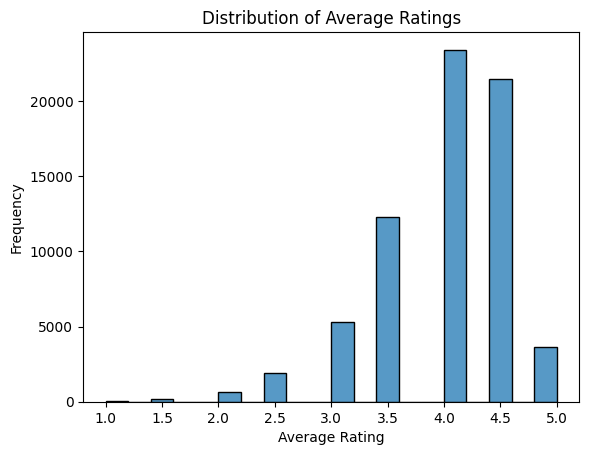

In [69]:
# Rating distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df_final["avg_rating"], bins=20)
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

Online ratings compress quality differences, making it difficult to distinguish between average and truly outstanding restaurants. 

If almost all have a good score, then a 4.5 doesn't mean really good it might mean normal. Ratings are not telling the whole story

From a professional perspective, this is problematic:

In a real culinary evaluation, quality differences between restaurants can be significant, but such differences are not reflected in the rating distribuition
this is both frustrating for the professional and for the customer in the seek of a good place to eat.

### Insight 2: Restaurants with few reviews show instable ratings as predicted

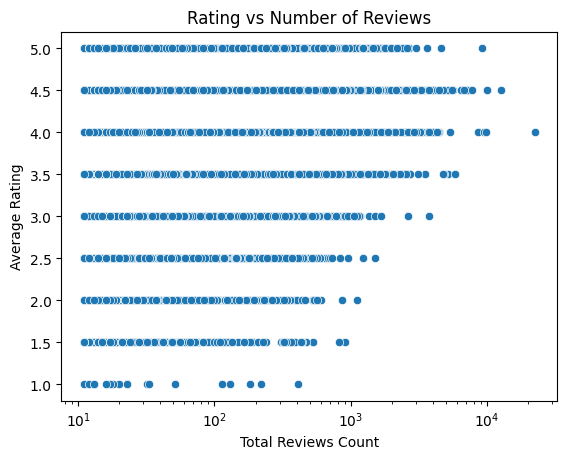

In [27]:
#Review vs rating
sns.scatterplot(x="total_reviews_count", y="avg_rating", data=df_final)
plt.xscale("log")
plt.title("Rating vs Number of Reviews")
plt.xlabel("Total Reviews Count")
plt.ylabel("Average Rating")
plt.show()

On the left (fewer reviews) we have restaurants with 1, 5 or any number of ratings (highly variable), in the right (more reviews) the ratings tend to concentrate from 3.5-4.5.

We can say that the rating tends to normalize, less extremes or "more reliable".

While that is actually true, and ratings based on a small number of reviews should be treated with caution, we still have the problem mentioned in the insight 1.

That would mean that restaurants with more visibility tend to look more "average" an INFLATED average

And the ones that don't have visibility are not really reliable. 

A complicated scene. 

### Insight 3: Paying more doesn't guarantee a better experience

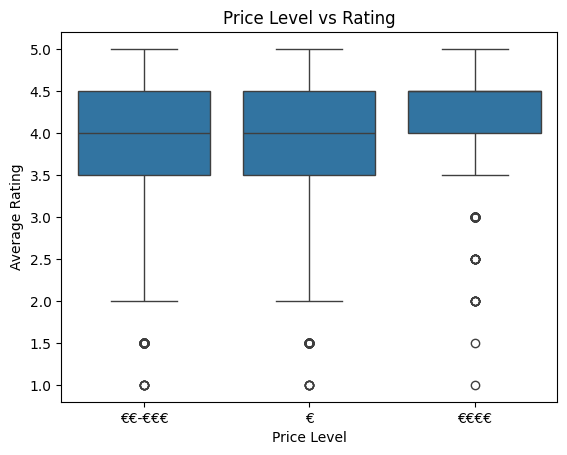

In [29]:
#Price level vs rating
sns.boxplot(x="price_level", y="avg_rating", data=df_final)
plt.title("Price Level vs Rating")
plt.xlabel("Price Level")
plt.ylabel("Average Rating")
plt.show()

The price doesn't change the average rating, although high-end restaurants show greater variability. That might be explained for the customer's expectations after paying a high price. 

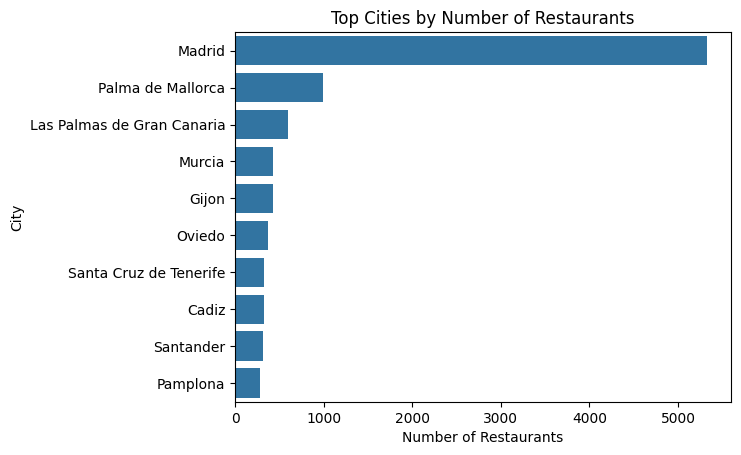

In [31]:
# Top 10 cities by number of restaurants
top_cities = df_final["city"].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

Madrid is by far the city with the most number of restaurants. With more than 5000, being Palma de Mallorca the second one with 1000 aprox. and then all the others in a stable 500-400
and then decreasing depending on the cities (habitants play a key role here). 

This distribution reflects population size and tourism activity, but also reveals a strong geographic imbalance in the dataset.

### Important Consideration

The dataset focuses strictly on "restaurants", excluding bars and casual drinking establishments.

This is particularly relevant in Spain, where a large portion of the food industry operates through bars and hybrid places (tapas).

As a result, cities with strong tapas-bar culture may be underrepresented in this analysis.

### Key Insight

The dataset reflects **visibility and categorization biases**, not just real restaurant distribution. 

Madrid dominates because is more **visible** not because it has a better gastronomy or quality, but because it has more **tourism**, more reviews, more online pressence. 
quantity isn't equal to quality. 

Spain has more than 300 Michelin star restaurants, The Basken Contry is the region with more Michelin stars per m^2 in the planet. And Barcelona, that was the best restaurant in the world (disfrutar) is the 3rd city in Europe with more Michellin Stars .  

Catalonia is underrepresented, everything fits with the bias of the datset.

### Insight 4: Operational intensity (or open hours) doesn't necessarily improve ratings

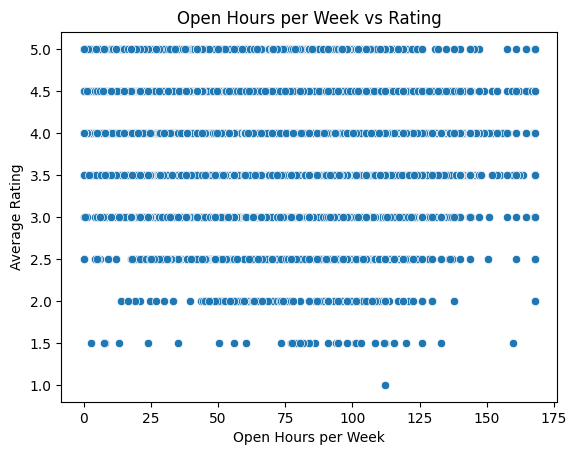

In [33]:
# Open hours per week vs rating # More hours = better rating? or creates burnout?
sns.scatterplot(x="open_hours_per_week", y="avg_rating", data=df_final)
plt.title("Open Hours per Week vs Rating")
plt.xlabel("Open Hours per Week")
plt.ylabel("Average Rating")
plt.show()

No Correlation with Quality: The analysis shows a near-zero correlation between weekly opening hours and the average rating. Exceptional ratings (5.0) are found in both exclusive restaurants open <30 hours and high-volume spots open >100 hours.

- Outlier Detection (The "Bar & Fast Food" Filter): Locations reporting >120 hours per week are statistical outliers for the "traditional restaurant" category. These typically represent:

- Nightlife & Bars: Establishments that prioritize drink service over dining.

- 24/7 Service: Gas stations, transport hubs, or fast-food chains.

- Data Integrity Warning: Data points approaching or exceeding 168 hours/week (the physical limit of a week) indicate overlapping shifts or data entry errors in the source, further justifying their removal to maintain a clean "sit-down restaurant" sample.

- Actionable Filter: To focus strictly on "Standard Dining," it is recommended to filter the dataset for establishments between 35 and 90 hours/week, as this range captures the typical lunch/dinner shift pattern in Spain.

### Food Quality, Service Quality or Value?

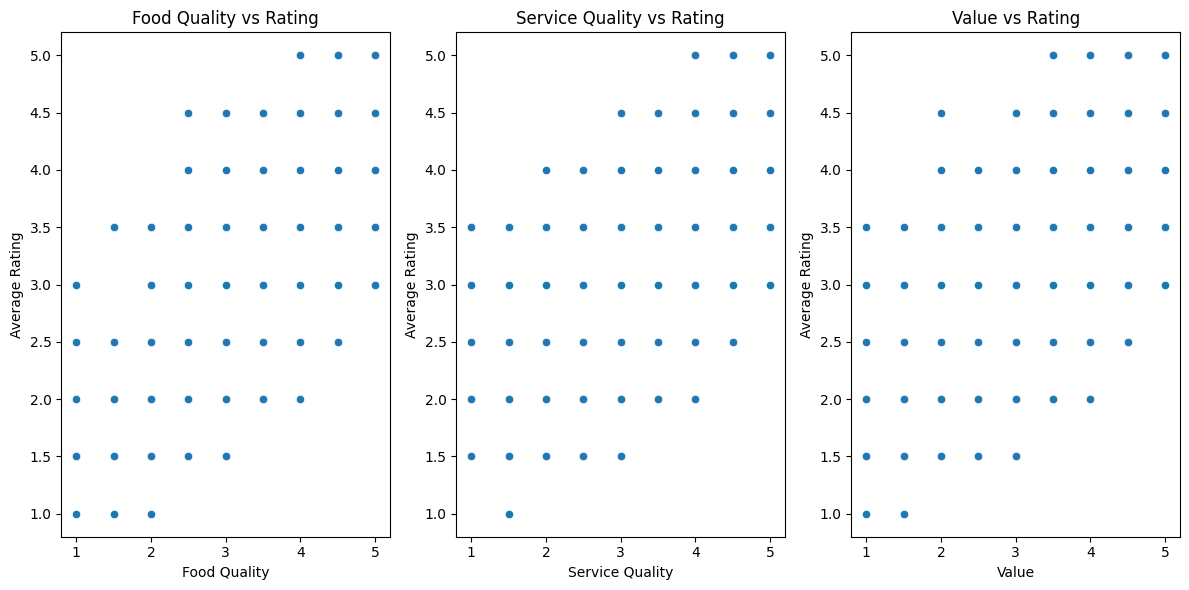

In [39]:
# let's put the food quality vs rating, food vs rating and service vs rating side by side to see if we can find some patterns
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.scatterplot(x="food", y="avg_rating", data=df_final)
plt.title("Food Quality vs Rating")
plt.xlabel("Food Quality")
plt.ylabel("Average Rating")

plt.subplot(1, 3, 2)
sns.scatterplot(x="service", y="avg_rating", data=df_final)
plt.title("Service Quality vs Rating")
plt.xlabel("Service Quality")
plt.ylabel("Average Rating")

plt.subplot(1, 3, 3)
sns.scatterplot(x="value", y="avg_rating", data=df_final)
plt.title("Value vs Rating")
plt.xlabel("Value")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

As we can see there is a positive correlation between all of them and the rating
but we can see that the food quality has a stronger correlation with the rating than the service and value, which is something that we expected.  

In [38]:
# to see it more clearly we can calculate the correlation matrix of these three variables with the rating
correlation_matrix = df_final[["food", "service", "value", "avg_rating"]].corr()
print(correlation_matrix["avg_rating"].sort_values(ascending=False))


avg_rating    1.000000
food          0.813803
service       0.797632
value         0.754236
Name: avg_rating, dtype: float64


### Key Insight

In statistics, a correlation greater than 0.7 is considered strong. All the variables have a strong correlation with the target column: avg_rating.

The food quality is a non-negotiable, if the food is bad, the avg_rating will be much lower even having other positive aspects.

The service is also really important, a good service might absorb the damage of a mediocre food (hardly a bad one) but only to a certain extain.

The value, while being strong, has a lower relationship (while remaining strong) due to the price factor. For example: The food and treatment might be a 5.0 but as a value 
it's percieved as a 3.0 due to being too expensive. This makes a bit of noise in the correlation. 
a 3.0

## Operational Segmentation

In [54]:
def classify_by_hours(hours):
    if pd.isna(hours) or hours <= 0:
        return 'Invalid/Missing'
    
    elif hours > 168:
        return 'Data Error (Exclude)'
    
    elif hours >= 120:
        return 'Non-Dining (Bars / 24h / Fast Food)'
    
    elif 80 <= hours < 120:
        return 'High-Intensity Restaurant'
    
    elif 40 <= hours < 80:
        return 'Standard Restaurant'
    
    elif hours < 40:
        return 'Low-Intensity / Premium / Limited Service'
    
    else:
        return 'Other'

df_final['category_check'] = df_final['open_hours_per_week'].apply(classify_by_hours)

df_rest_clean = df_final[df_final['category_check'].isin(['Standard Restaurant','High-Intensity Restaurant','Low-Intensity / Premium / Limited Service'])].copy()

print(df_rest_clean['category_check'].value_counts())
print()
print(df_final['category_check'].value_counts())
print()
print("Number of missing values in open_hours_per_week:")
print(df_final['open_hours_per_week'].isna().sum())

category_check
Standard Restaurant                          18022
Low-Intensity / Premium / Limited Service    12009
High-Intensity Restaurant                    11545
Name: count, dtype: int64

category_check
Invalid/Missing                              27330
Standard Restaurant                          18022
Low-Intensity / Premium / Limited Service    12009
High-Intensity Restaurant                    11545
Non-Dining (Bars / 24h / Fast Food)           1388
Name: count, dtype: int64

Number of missing values in open_hours_per_week:
27302


### - There are a lot of Invalid/Missing values. That's why, instead of replacing the original values, we created a Subset of Analysis.

### - We have 27302 Missing Values, that might be because in TripAdvisor, the smallest restaurants might not have registered open_hour_per_week, so dropping them would not be a good idea

### - But, What we can do is remove the Non-Dining (Bars/ 24h/ Fast Food) since they are a small proportion (1388) and useless/not accurate

In [55]:
df_final = df_final[df_final['category_check'] != 'Non-Dining (Bars / 24h / Fast Food)']
print(df_final.shape)

(68906, 43)


Restaurants were classified based on weekly opening hours to better reflect real operational models.

This allows us to distinguish between:
- Standard restaurants
- High-intensity operations
- Low-intensity / premium establishments

This classification helps remove non-representative entities such as bars or 24/7 establishments, ensuring a more accurate analysis of traditional dining businesses.

In [43]:
# Finally let's see the average rating to confirm, that food quality is indeed appretiated by the customers.
df_rest_clean.groupby("category_check")["avg_rating"].mean()

category_check
High-Intensity Restaurant                    3.890270
Low-Intensity / Premium / Limited Service    4.260098
Standard Restaurant                          4.110214
Name: avg_rating, dtype: float64

As we can see above, the higher the intensity, the lower it is the mean average. That is directly related to the food quality. A the most correlated feature
High intensity Restaurants tend to offer worse quality food (like frozen food) than a restaurant that has more time and well-rested workers. The burnout factor...
More hours don’t mean better restaurants, operational focus and consistency do.

In [56]:
df_final.shape


(68906, 43)

In [46]:
df_final.columns

Index(['restaurant_link', 'restaurant_name', 'original_location', 'country',
       'region', 'province', 'city', 'address', 'latitude', 'longitude',
       'claimed', 'awards', 'popularity_detailed', 'popularity_generic',
       'top_tags', 'price_level', 'price_range', 'meals', 'cuisines',
       'special_diets', 'features', 'vegetarian_friendly', 'vegan_options',
       'gluten_free', 'original_open_hours', 'open_days_per_week',
       'open_hours_per_week', 'working_shifts_per_week', 'avg_rating',
       'total_reviews_count', 'default_language',
       'reviews_count_in_default_language', 'excellent', 'very_good',
       'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere',
       'keywords', 'category_check'],
      dtype='str')

## Key Findings

### 1. Rating Inflation
Ratings are heavily concentrated between 4.0 and 4.5, limiting their ability to differentiate true quality.

### 2. Review Reliability
Restaurants with fewer reviews show highly unstable ratings, making them unreliable indicators of performance.

### 3. Price =/= Quality
Higher prices do not significantly correlate with higher ratings, suggesting that cost is not a primary driver of satisfaction.

### 4. Experience > Product
Food quality, service, and perceived value all strongly correlate with ratings, indicating that customer satisfaction is driven by the overall experience.

### 5. Operational Intensity Matters
Restaurants with lower operational intensity (fewer opening hours) tend to achieve higher ratings, suggesting that consistency and focus are key to success.

### 6. Geographic and Visibility Bias
The dataset overrepresents highly visible cities like Madrid, while underrepresenting regions with strong culinary reputation.

# Feature engineering

We will start by creating a new metric, the **success index**. The idea is to combine average rating, total reviews and excellent scores. 

## Success index:

In [70]:
# Ratio of excellents (proportion)
df_final['excellent_ratio'] = df_final['excellent'] / df_final['total_reviews_count']

# Success index: rating × log(reviews) × ratio of excellents
# It's VERY important to use log here, othwerwise the restaurants with more reviews will always have a higher index.
# np.log1p is used instead of np.log to handle the case when total_reviews_count is 0, although we have already filtered those out, it's a good practice to use log1p to avoid any potential issues with log(0). 
df_final['success_index'] = (
    df_final['avg_rating'] * 
    np.log1p(df_final['total_reviews_count']) * 
    df_final['excellent_ratio']
)

# Verification:
print(df_final['excellent_ratio'].describe())
print()
print(df_final['success_index'].describe())
print()
print(df_final[['restaurant_name', 'avg_rating', 'total_reviews_count', 'excellent_ratio', 'success_index']].head(10))

count    68884.000000
mean         0.175730
std          0.213667
min          0.000000
25%          0.022727
50%          0.077670
75%          0.263158
max          1.000000
Name: excellent_ratio, dtype: float64

count    68884.000000
mean         2.942356
std          3.777121
min          0.000000
25%          0.393253
50%          1.282260
75%          4.195631
max         33.504416
Name: success_index, dtype: float64

                        restaurant_name  avg_rating  total_reviews_count  \
0                    Taiet d'Ullastrell         4.0                236.0   
1                            La Dorotea         4.5                193.0   
2                        Sabores Tejeda         4.0                136.0   
3  Restaurante Asador-Grill El Almendro         4.0                311.0   
4                     Restaurante Gayfa         3.5                108.0   
5                     La Tienda de Paco         4.0                100.0   
6           Texeda Brewery & Restaurant 

### Conclusions of Success Index:

Mean of 2.94 (Median of 1.94) with a max value of 33.5

As it is expected, most of the restaurants have a modest index, the percentile 75 has a value of 4.19, so only the top 25% have a value greater than that. 

Looking at specific examples from the head display it makes sense:
Row number 9, Casa del Camionero, rating of 4.5, 454 reviews, 20% excellent --> 5.64 success index
Row number 0, Taiet d'Ullastrell, rating of 4.0, 236 reviews, but only 0.4% are excellent --> 0.09 success index

### We acomplished what we wanted: punish the inflated ratings with few excellent reviews

## Polarization Ratio

In [71]:
df_final['polarization_ratio'] = (
    df_final['excellent'] / 
    (df_final['excellent'] + df_final['terrible']).replace(0, np.nan)
)
print(df_final['polarization_ratio'].describe())

count    63207.000000
mean         0.856189
std          0.237150
min          0.000000
25%          0.800000
50%          0.982456
75%          1.000000
max          1.000000
Name: polarization_ratio, dtype: float64


In [72]:
print(df_final[['restaurant_name', 'excellent', 'terrible', 'polarization_ratio']].head(10))

                        restaurant_name  excellent  terrible  \
0                    Taiet d'Ullastrell        1.0       0.0   
1                            La Dorotea       17.0       0.0   
2                        Sabores Tejeda        8.0       2.0   
3  Restaurante Asador-Grill El Almendro       16.0       2.0   
4                     Restaurante Gayfa        7.0       0.0   
5                     La Tienda de Paco        6.0       1.0   
6           Texeda Brewery & Restaurant       42.0       0.0   
7                       Cueva de la Tea       31.0       2.0   
8                           El Labrador       14.0       6.0   
9                     Casa del Caminero       93.0       4.0   

   polarization_ratio  
0            1.000000  
1            1.000000  
2            0.800000  
3            0.888889  
4            1.000000  
5            0.857143  
6            1.000000  
7            0.939394  
8            0.700000  
9            0.958763  


### Conclusions of Polarization Ratio:

As we can see, with a mean of 0.85, a median of 0.98 and a percentile 25 of 0.8 and a percentile 75 of 1. This dataset is extremly polarized.
It makes sense when it comes to a restaurant, it is either good or bad, there are no mixed extreme opinions about one place 

## Digital maturity

Claimed Column =  Indicates if the restaurant's owner has officially claimed their profile in the platform. 

If claimed = 1 Owners can make changes on their profile, like update information, schedules, post photos, answer reviews... a digital proficency
If claimed = 0 The profile has been created automatically. Less control, less interaction

In [85]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize components to ensure they are on the same scale before combining them into the digital maturity score. This prevents one component from dominating the score due to its scale.
df_final['claimed_bin'] = (df_final['claimed'] == 'Claimed').astype(int)
df_final['log_reviews_scaled'] = scaler.fit_transform(
    df_final[['total_reviews_count']].apply(np.log1p)
)

# Digital maturity
df_final['digital_maturity'] = (
    0.5 * df_final['claimed_bin'] + 
    0.5 * df_final['log_reviews_scaled']
)

# Verification
print(df_final['digital_maturity'].describe())
print(f"\nClaimed breakdown:")
print(df_final['claimed_bin'].value_counts())

count    68884.000000
mean         0.412473
std          0.284306
min          0.000000
25%          0.093416
50%          0.551338
75%          0.657689
max          1.000000
Name: digital_maturity, dtype: float64

Claimed breakdown:
claimed_bin
1    40391
0    28493
Name: count, dtype: int64


### Conclusions of Digital Maturity:

Digital maturity combines two signals: whether the owner has claimed their profile and their review volume (normalized). 

59% of restaurants have claimed their profile, suggesting active digital engagement.
However, the distribution shows high variance (std: 0.28), indicating a clear gap between digitally mature establishments and those with minimal online presence.

A low digital maturity score doesn't necessarily mean a bad restaurant, it may simply reflect a local or family business that relies on word-of-mouth rather than online visibility. The "Hidden Gems" of the villages for example

## Menu focus

In [87]:
# Menu focus: number if cuisines offered. This is interesting, a focused menu is a requisite for expertise and fresh products, on the other hand an unfocused one can attact customers even with lower quality.
df_final['menu_focus'] = df_final['cuisines'].str.split(',').apply(
    lambda x: len(x) if isinstance(x, list) else np.nan
)

print(df_final['menu_focus'].describe())
print(df_final['menu_focus'].value_counts().head(10))

count    64988.000000
mean         2.393842
std          1.251897
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         13.000000
Name: menu_focus, dtype: float64
menu_focus
2.0     21166
1.0     17643
3.0     14593
4.0      7861
5.0      2647
6.0       700
7.0       244
8.0        57
9.0        30
10.0       22
Name: count, dtype: int64


In [88]:
# The most specialized restaurants hace a better success index?
df_final.groupby('menu_focus')['success_index'].mean().head(10)

menu_focus
1.0     2.503987
2.0     2.790661
3.0     3.107803
4.0     3.533242
5.0     3.856257
6.0     4.142931
7.0     4.218272
8.0     5.376108
9.0     4.030149
10.0    2.935502
Name: success_index, dtype: float64

In [89]:
# Restaurants with more cuisines have more reviews?
df_final.groupby('menu_focus')[['total_reviews_count', 'avg_rating']].mean().head(10)

,total_reviews_count,avg_rating
menu_focus,,
1.0,76.748002,3.783994
2.0,103.405509,3.963550
3.0,209.287055,4.076886
4.0,291.518127,4.138278
5.0,364.814129,4.229127
6.0,373.274286,4.360714
7.0,415.627049,4.338115
8.0,445.070175,4.517544
9.0,364.133333,4.516667


In [90]:
# Pure rating without volume effect, to see if the most specialized restaurants have better ratings even without the effect of having more reviews.
df_final.groupby('menu_focus')['avg_rating'].mean().head(10)

menu_focus
1.0     3.783994
2.0     3.963550
3.0     4.076886
4.0     4.138278
5.0     4.229127
6.0     4.360714
7.0     4.338115
8.0     4.517544
9.0     4.516667
10.0    4.545455
Name: avg_rating, dtype: float64

In [92]:
# different values of the cuisines column
print(df_final['cuisines'].value_counts().head(20))

cuisines
Spanish                                      13194
Mediterranean, Spanish                        8161
Spanish, Mediterranean                        4448
Mediterranean, European, Spanish              3393
Mediterranean                                  982
Seafood, Mediterranean, European, Spanish      868
Italian, Pizza                                 816
Chinese, Asian                                 790
Japanese, Sushi, Asian                         771
Mediterranean, Spanish, European               742
Italian, Pizza, Mediterranean, European        740
Seafood, Mediterranean, Spanish                706
European, Spanish                              545
Spanish, Mediterranean, European               465
Italian, Pizza, Mediterranean                  439
Italian                                        432
Mediterranean, European, Spanish, Catalan      427
American                                       410
Steakhouse, Spanish                            410
Seafood, Spanish      

### Conclusions of Menu Focus:

Contrary to the initial hypothesis, restaurants with more cuisine types registered show higher ratings and more reviews. However, this likely reflects establishment size and visibility rather than menu quality.

A restaurant tagged with 6 cuisines on TripAdvisor is probably a large, well-resourced establishment — not necessarily one with better food.

Menu focus as derived from TripAdvisor tags is a limited proxy for actual menu complexity. **This variable should be interpreted with caution.**

Also, we can see some restaurants tagged with: "Spanish, Catalan, Mediterranean, Seafood, European..." Does that mean 5 different cousines? Absolutely NOT in fact, it is **only one**.

In [93]:
# As we can see the variable menu_focus has a lot of noise and should be removed
df_final.drop('menu_focus', axis=1, inplace=True)

# Expert perspective

From a professional kitchen perspective, restaurant quality is influenced by factors that are not fully captured in online ratings.

Technical execution, ingredient quality, and kitchen complexity often go unnoticed by the average customer, who may prioritize service, speed, and overall experience.

This creates a gap between perceived success and actual culinary excellence.

# Data-Driven Restaurant Strategy

Based on the analysis, an optimal restaurant strategy would include:

- Moderate pricing (accessible but not low-cost)
- Controlled operational hours to maintain consistency
- Strong focus on service quality
- Balanced menu complexity (dishes with mise en place to save time and reduce stress in high demand hours)
- Inclusion of familiar or “universal” dishes (For example, in Spain: patatas bravas, croquetas..., with a special touch of distinction) to meet customer expectations, give them a reason to remember you

This combination maximizes perceived value while maintaining operational sustainability.


### Què fem amb vegetarian, vegan etc...? Les columnes q no utilitzi fora
### Latitude longitude i tal, puc deixar per el tableau si vull fer un dashboard